# Rectangular Waveguide Analysis

This notebook demonstrates a complete rectangular waveguide analysis workflow:

1. Geometry creation
2. Frequency-domain analysis
3. Model order reduction
4. Comparison with analytical solution

In [1]:
from utils.visualization import *
from geometry.primitives import RectangularWaveguide
from solvers.frequency_domain import FrequencyDomainSolver
from rom.reduction import ModelOrderReduction
from analytical.rectangular_waveguide import RWGAnalytical
from ngsolve.webgui import Draw # must import Draw, otherwise may run into problems showing mesh

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

In [2]:
# %%time
# %%timeit -n 3 -r 5
# %time modes, basis = solver.solve(nmodes=3)

## 1. Define Geometry

Create a rectangular waveguide with specified dimensions and mesh parameters.

In [3]:
# Waveguide parameters
a = 100e-3  # Width: 100 mm
L = 200e-3  # Length: 200 mm
maxh = 0.04  # Mesh size

# Create waveguide geometry
rwg = RectangularWaveguide(a=a, L=L, maxh=maxh)
# save step file
rwg.save_step(r"./rectangular_waveguide.step")

print(f"Dimensions: a={a * 1e3:.0f}mm, b={rwg.b * 1e3:.0f}mm, L={L * 1e3:.0f}mm")
print(f"Cutoff frequency (TE10): {rwg.cutoff_frequency_TE10 / 1e9:.3f} GHz")
print(f"Mesh DOFs: ~{rwg.mesh.nv} vertices")

rwg.show('mesh')

Geometry saved to: rectangular_waveguide.step
Dimensions: a=100mm, b=50mm, L=200mm
Cutoff frequency (TE10): 1.499 GHz
Mesh DOFs: ~48 vertices


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

## 2. Full-Order Numerical Solution

Run a full-order finite element frequency sweep.


Structure Topology
Type: Single structure
Domains (1): ['vacuum']
Total Ports (2): ['port1', 'port2']

Domain-Port Mapping:
  vacuum: ['port1 (external, input)', 'port2 (external, output)']

Assembling Matrices...

Solving port eigenmodes...

	Calculating Port Eigenmodes...
	  Mode source: analytic
	  Polarization angle: 0.0°
	  Requested modes per port: 2
	------------------------------------------------------------
	  port1: rectangular (fit error: 0.0000)
	    a=0.100000, b=0.050000
	  port2: rectangular (fit error: 0.0000)
	    a=0.100000, b=0.050000
	  Precomputing boundary mass matrices (once per port)...
	    Done for 2 port(s)
	port1 mode 0: TE_10, kc=31.4159, σ=+1
	port1 mode 1: TE_01, kc=62.8319, σ=+1
	port2 mode 0: TE_10, kc=31.4159, σ=-1
	port2 mode 1: TE_01, kc=62.8319, σ=-1
	------------------------------------------------------------
	Total modes: 4

--- Assembling Per-Domain Matrices ---

Domain: vacuum
  FES ndof: 2900
  K shape: (2900, 2900), nnz: 271120
  M shape: (

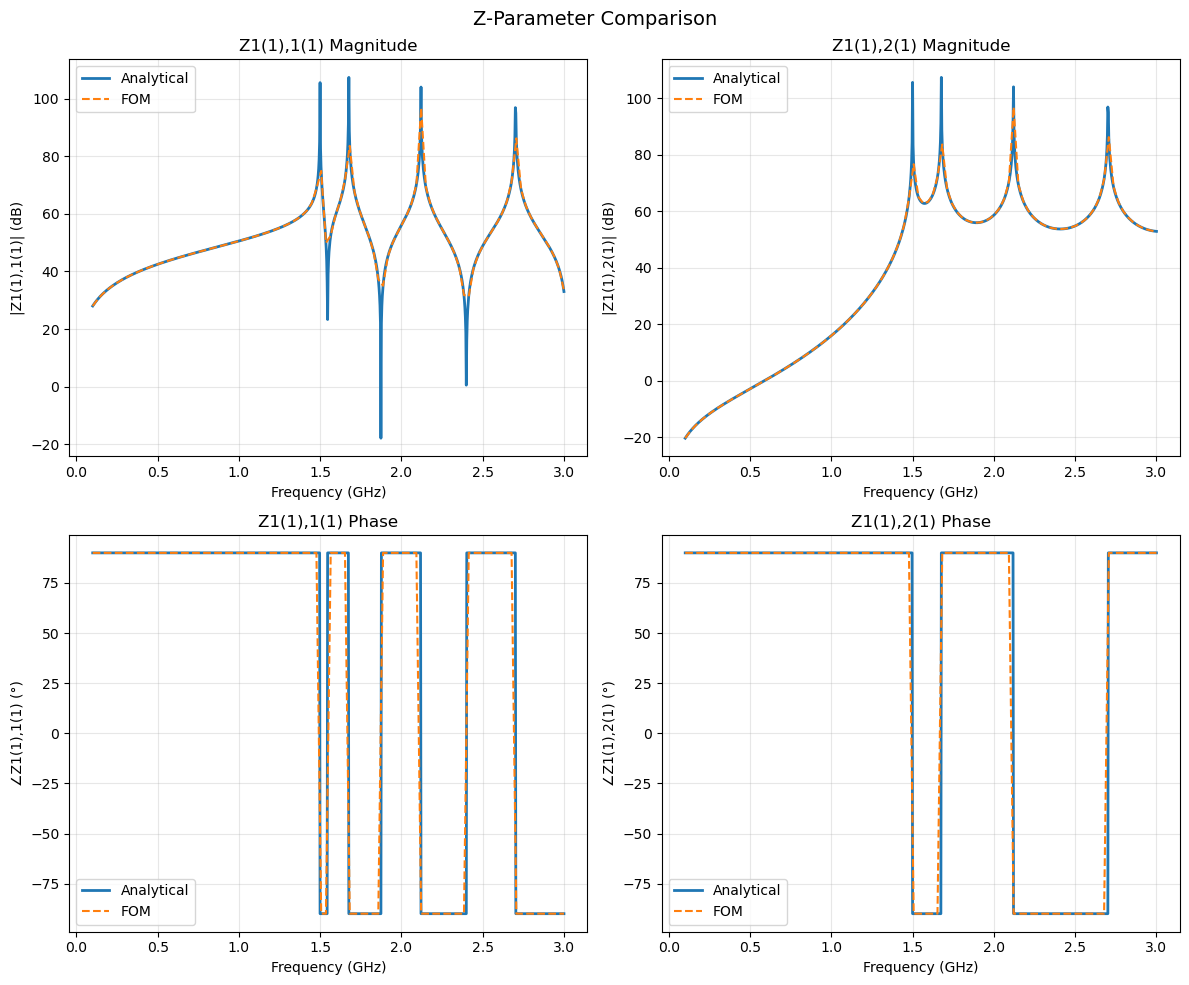

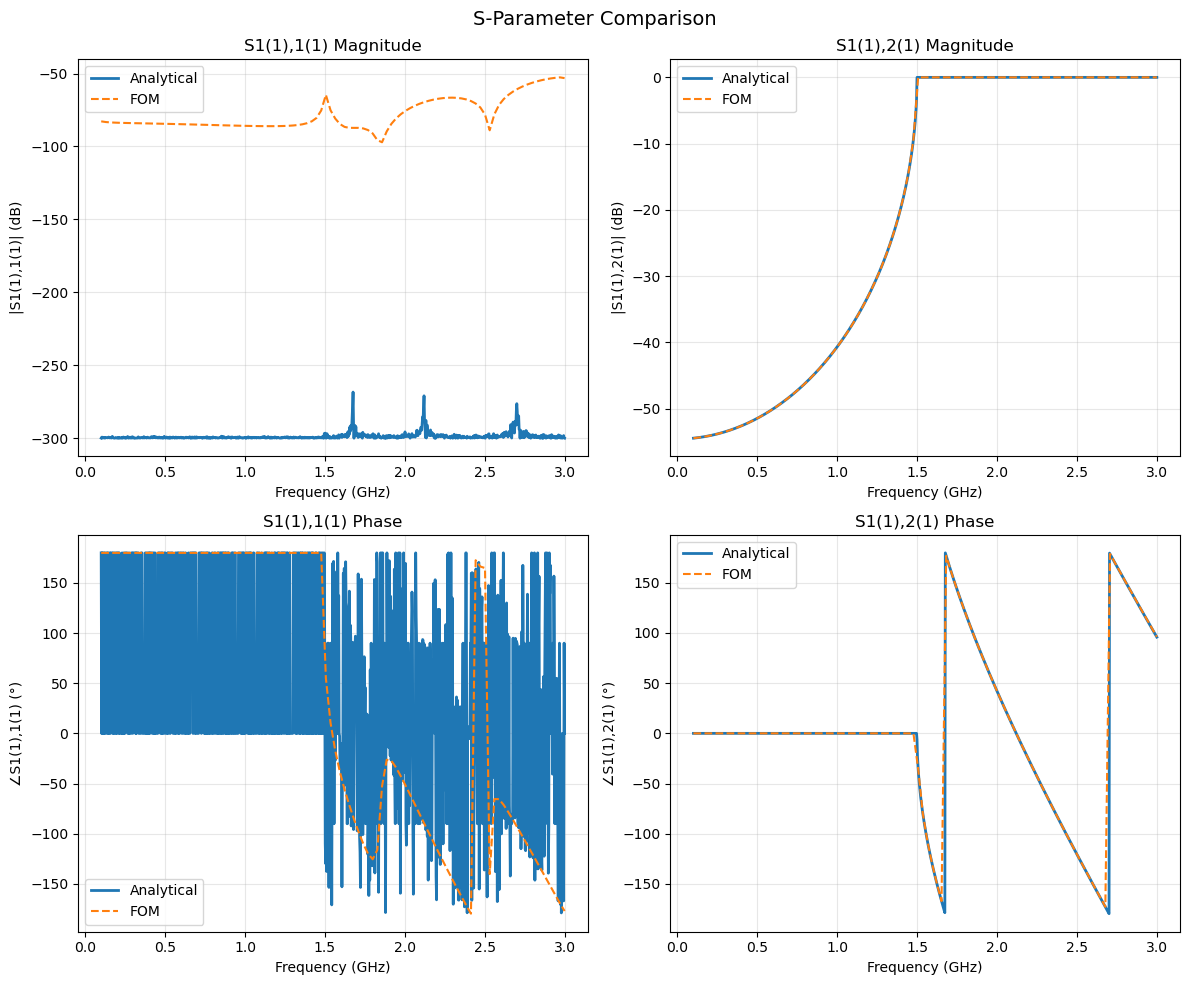

(<Figure size 1200x1000 with 4 Axes>,
 {'S1(1),1(1)_mag': <Axes: title={'center': 'S1(1),1(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),1(1)| (dB)'>,
  'S1(1),1(1)_phase': <Axes: title={'center': 'S1(1),1(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),1(1) (°)'>,
  'S1(1),2(1)_mag': <Axes: title={'center': 'S1(1),2(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),2(1)| (dB)'>,
  'S1(1),2(1)_phase': <Axes: title={'center': 'S1(1),2(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),2(1) (°)'>})

In [4]:
# 2. Analytical
a = 100e-3  # Width: 100 mm
L = 200e-3  # Length: 200 mm
analytical = RWGAnalytical(a=a, L=L)


# 3. FOM solve
fmin, fmax, nf = 0.1, 3, 100
fds = FrequencyDomainSolver(rwg, order=3)
fds.assemble_matrices(nportmodes=2)
fds.solve(fmin, fmax, nf, store_snapshots=True)

# 4. Quick comparison plots - just pass the objects!
frequencies = np.linspace(fmin, fmax, 1000) * 1e9
plot_z_comparison([analytical, fds], frequencies=frequencies)
plot_s_comparison([analytical, fds], frequencies=frequencies)

In [5]:
print(fds.Z_dict['2(1)1(1)'])
print(fds.Z_dict['1(1)2(1)'])

[ 0.+9.54014527e-02j  0.+1.24702004e-01j  0.+1.55070914e-01j
  0.+1.86785161e-01j  0.+2.20144471e-01j  0.+2.55476911e-01j
  0.+2.93145280e-01j  0.+3.33554510e-01j  0.+3.77160316e-01j
  0.+4.24479411e-01j  0.+4.76101659e-01j  0.+5.32704641e-01j
  0.+5.95071226e-01j  0.+6.64110898e-01j  0.+7.40885802e-01j
  0.+8.26642720e-01j  0.+9.22852589e-01j  0.+1.03125959e+00j
  0.+1.15394255e+00j  0.+1.29339214e+00j  0.+1.45260871e+00j
  0.+1.63522699e+00j  0.+1.84567635e+00j  0.+2.08938823e+00j
  0.+2.37306698e+00j  0.+2.70504658e+00j  0.+3.09576511e+00j
  0.+3.55840214e+00j  0.+4.10974503e+00j  0.+4.77138038e+00j
  0.+5.57135493e+00j  0.+6.54652501e+00j  0.+7.74593406e+00j
  0.+9.23575648e+00j  0.+1.11066810e+01j  0.+1.34851914e+01j
  0.+1.65512515e+01j  0.+2.05668689e+01j  0.+2.59238501e+01j
  0.+3.32269673e+01j  0.+4.34460695e+01j  0.+5.82115052e+01j
  0.+8.04329329e+01j  0.+1.15729644e+02j  0.+1.76212481e+02j
  0.+2.92660061e+02j  0.+5.68749214e+02j  0.+1.66686881e+03j
 -0.-6.77026562e+03j -0.

In [6]:
fds.port_solver.port_orientation_factors

{'port1': 1.0, 'port2': -1.0}

In [7]:
fds.plot_port_mode('port1')


Port Mode: port1 [external (input)], Mode 0
Cutoff frequency: 1.4990 GHz


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

In [8]:
fds.plot_port_mode('port2')


Port Mode: port2 [external (output)], Mode 0
Cutoff frequency: 1.4990 GHz


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

In [9]:
fds.plot_field(14)


Field visualization at f = 0.5101 GHz
Source: global
Excitation: port1, mode 0
Plotting: |E| (None)


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

CPU times: total: 0 ns
Wall time: 0 ns

Model Order Reduction

Domain: vacuum
  Using global snapshots (single-domain structure)
  Full DOFs: 2900
  Snapshots: 400
  Reduced DOFs: 28
  Compression: 99.0%
  Singular value decay: 8.10e+05 → 3.42e-01

------------------------------------------------------------
Total: 2900 → 28 DOFs
Overall compression: 99.0%
CPU times: total: 609 ms
Wall time: 427 ms
CPU times: total: 5.17 s
Wall time: 1.23 s


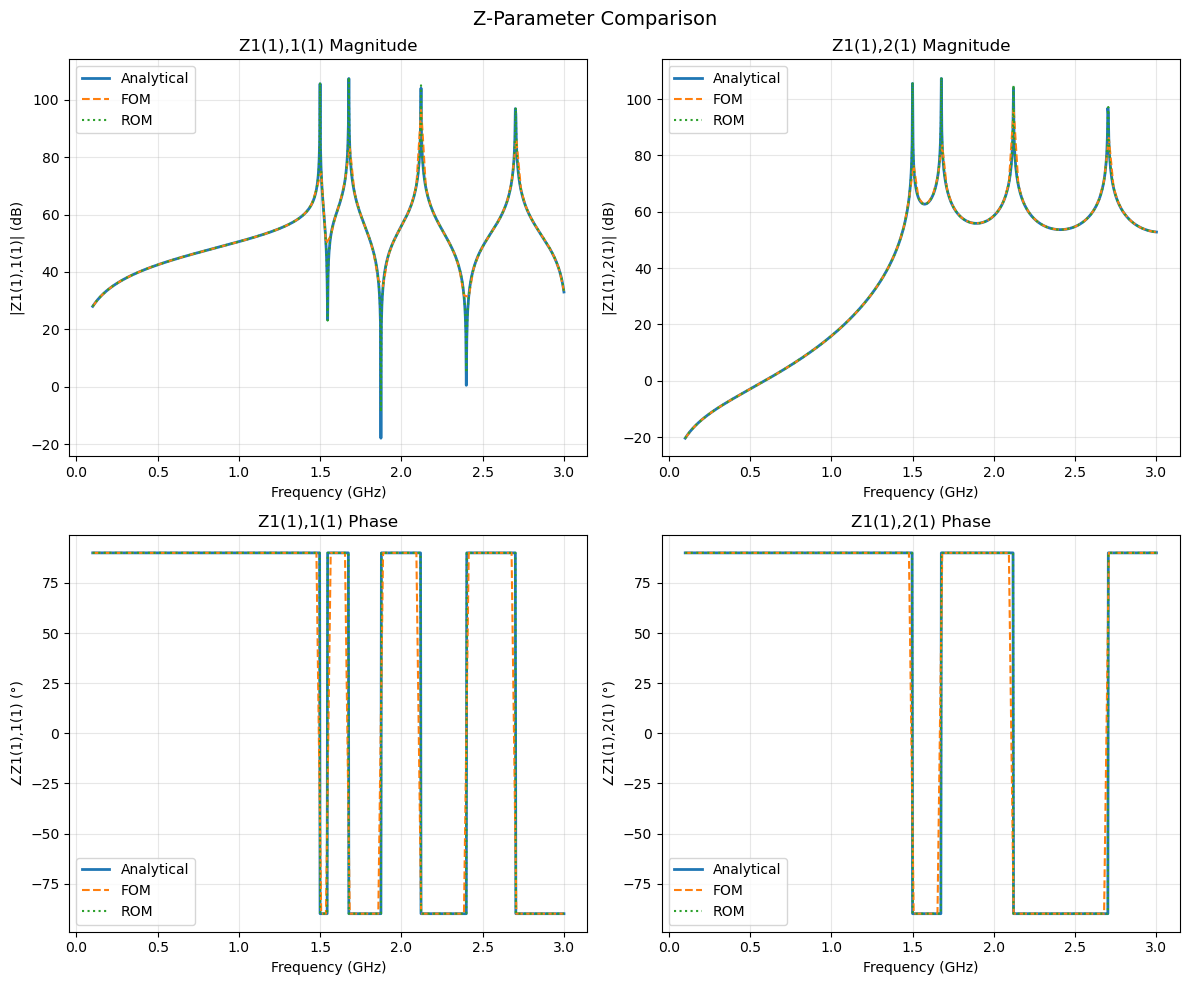

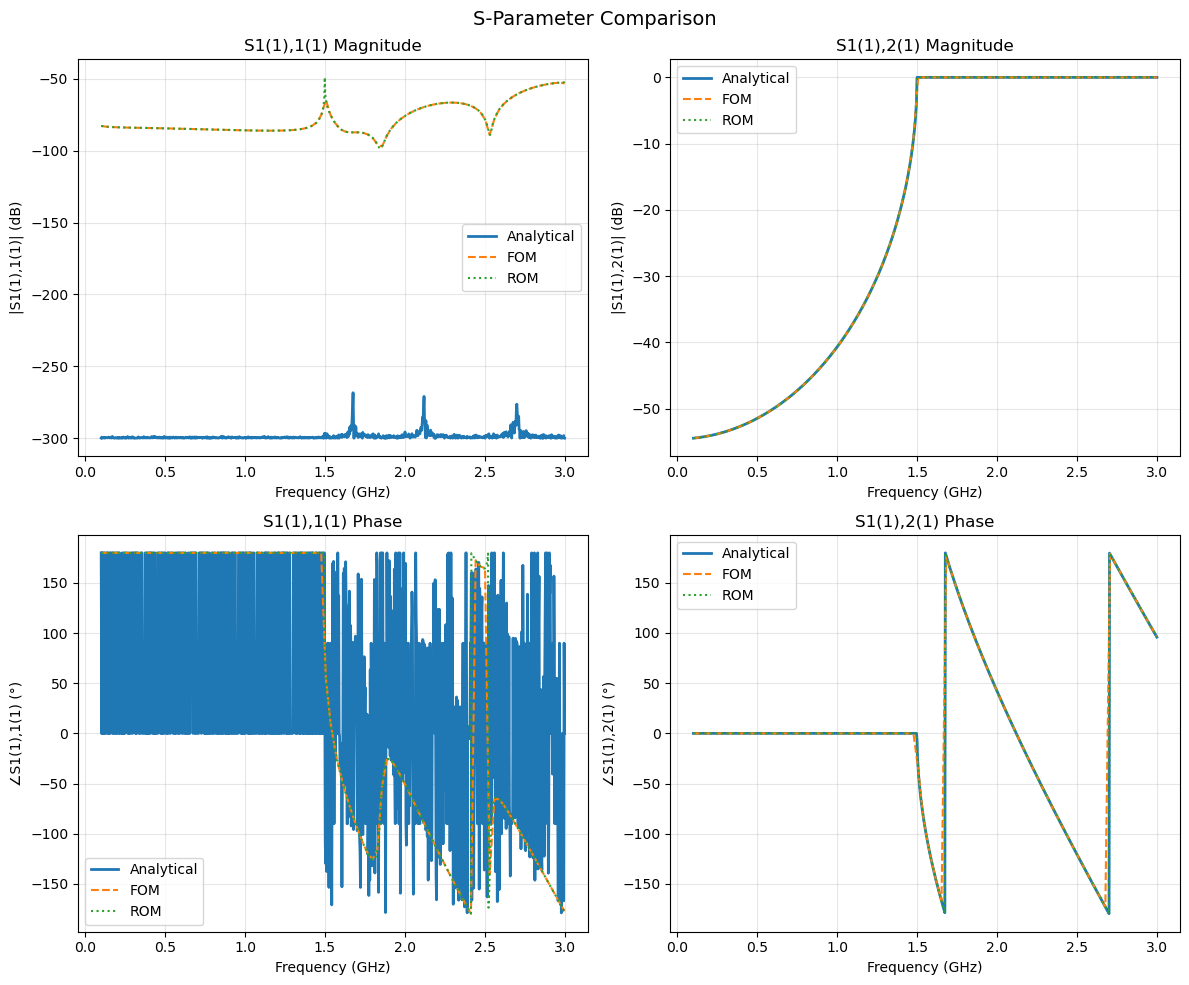

(<Figure size 1200x1000 with 4 Axes>,
 {'S1(1),1(1)_mag': <Axes: title={'center': 'S1(1),1(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),1(1)| (dB)'>,
  'S1(1),1(1)_phase': <Axes: title={'center': 'S1(1),1(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),1(1) (°)'>,
  'S1(1),2(1)_mag': <Axes: title={'center': 'S1(1),2(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),2(1)| (dB)'>,
  'S1(1),2(1)_phase': <Axes: title={'center': 'S1(1),2(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),2(1) (°)'>})

In [10]:
# After ROM is working...
from rom.reduction import ModelOrderReduction

%time rom = ModelOrderReduction(fds)
%time rom.reduce(max_rank=100, tol=1e-6)
%time rom.solve(fmin, fmax, 1000)

# Compare all three
plot_z_comparison([analytical, fds, rom], frequencies=frequencies,
                  labels=['Analytical', 'FOM', 'ROM'])
plot_s_comparison([analytical, fds, rom], frequencies=frequencies,
                  labels=['Analytical', 'FOM', 'ROM'])


(1.0, 5.0)

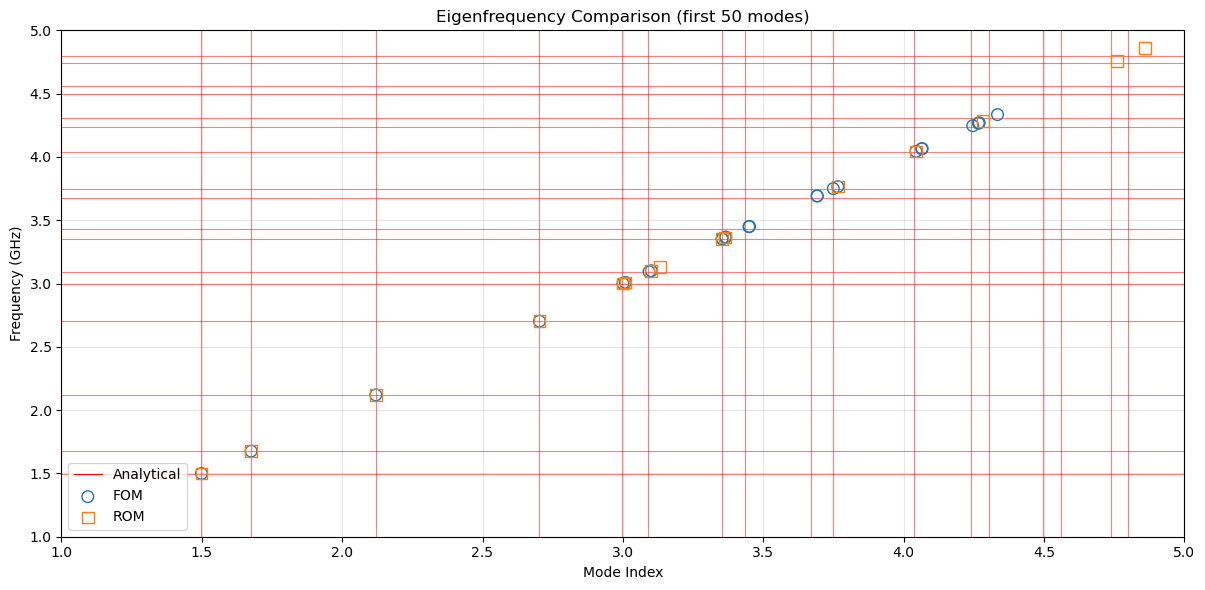

In [11]:
fig, ax = plot_eigenfrequencies([fds, rom], analytical=analytical,
                      labels=['FOM', 'ROM'], n_modes=50)
ax.set_ylim(1, 5)
ax.set_xlim(1, 5)